# Case 1: Piccolo Doppio (FLMS) field spectroradiometer - uncertainty propagation from DN to vegetation indices (VI), full pipeline

## GOAL
This notebook provides a complete, end-to-end example of uncertainty propagation for a 
Piccolo Doppio system. This system uses two optical configurations to measure upwelling and 
downwelling radiation.
The workflow starts from raw detector counts (DN - digital numbers) and ends with derivation of different relevant vegetation indices and their 
propagated uncertainties. 
Uncertainty is propagated through every processing step, including 
the complete radiometric calibration and validation chain.
The notebook uses the actual calibration and vegetation-index functions and runs them on a real 
measurement example from the 2025 Norway field campaign: the FLMS detector, Plot 103.

## WHY DO WE NEED THE CALIBRATION STEP?
A spectrometer's raw output is a digital count, not a physical quantity. To turn these counts into 
scientifically meaningful measurements, they must be traced to physical units through an
unbroken chain of comparisons with reference standards.
This notebook follows three stages in the calibration and validation chain, each one bringing
the measurement traceability closer to the conditions under which the field measurements were
made:
1. Laboratory calibration: the detector's raw response is related to a radiance or irradiance standard 
    under controlled laboratory conditions.
2. Laboratory validation (here with ValGEOS): the laboratory calibration is checked against an independent transfer 
   standard before the instrument leaves the laboratory.
   This provides independent confirmation that the calibration performs as expected.
3. Field validation: the laboratory-validated calibration is checked again under field 
   conditions using a validation measurement. This step assesses whether the calibration remains valid 
   after transport and under the environmental conditions of the campaign, and can reveal changes 
   associated with factors such as temperature, elapsed time or instrument handling.

After the calibration and validation stages, the field data are processed through the following chain:
field measurements at 5 points → reflectance → plot mean → five vegetation indices (NDVI, EVI, OSAVI, MTCI, PRI)
At each stage, the associated measurement uncertainty is propagated to the next stage.
This makes it possible to quantify not only the final vegetation-index values, but also the uncertainty 
associated with those values and how that uncertainty has accumulated through the processing chain. 

> **Note:** The same calibration chain structure and code apply to any dual-fibre
> spectrometer built around Ocean Insight QE-series detectors (cosine
> diffuser for irradiance, collimator or bare fibre for radiance), for example FLOX devices.
> Point the loader at your own raw files, in the same format, and it runs unchanged.

## STEP 1 - Import the relevant Python packages needed in this notebook



In [1]:
# =====================================================================================
# OVERVIEW
# INPUT DATA        : raw detector counts (light and dark scans, integration times, wavelengths) of the
#                     Piccolo Doppio FLMS detector for the radiance (L) and irradiance (E) channels:
#                       - laboratory calibration (2023) against radiance / irradiance standards
#                       - laboratory validation against the transfer standard ValGEOS (2023)
#                       - field validation measurement of ValGEOS (2025, Norway)
#                       - field measurements, Plot 103, 5 points (2025)
#                     plus the standards' uncertainties and the detector non-linearity coefficients.
# ASSUMPTIONS       : random effects are independent between wavelengths and between measurements;
#                     systematic effects (standards, non-linearity residual, cosine response) are fully
#                     correlated over wavelength; the cosine-response uncertainty is rectangular.
# UNCERTAINTY MODEL : every quantity is carried as (value, u_random, u_systematic), kept separate.
#                     Each processing step is a function; its uncertainty is propagated with punpy
#                     (Monte Carlo, N_MC samples) separately for the random and the systematic part.
# STEPS             : 1 lab calibration -> 2 lab validation (ValGEOS) -> 3 field calibration
#                     -> 4 field measurement: L, E, reflectance R = pi*L/E (per point)
#                     -> 4b plot mean over 5 points -> 5 vegetation indices (per point)
#                     -> 6 comparison with the campaign indices
# OUTPUT            : calibration coefficients, calibrated L and E, reflectance and its uncertainty,
#                     plot-mean reflectance, NDVI / EVI / OSAVI / MTCI / PRI with random and
#                     systematic uncertainty; plots of each stage.
# =====================================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import punpy

# Folder with the Plot 103 data (text files, one per quantity); sensor and plot to process
DATA_DIR = Path("../data/case-piccolo-plot103-full")
sensor = "FLMS"
plot_id = "103"
# Wavelength window used in all plots (nm) and number of Monte Carlo samples for punpy
WL_MIN, WL_MAX = 400, 900   # FLMS detector's usable wavelength range
N_MC = 10000                 # punpy Monte Carlo sample size
k = 2                        # expansion factor for reporting (not used directly below)

# punpy Monte Carlo propagation object used in every stage
prop = punpy.MCPropagation(N_MC, parallel_cores=1)

import matplotlib.pyplot as plt

# Helpers: read a text file; make column vectors; scale counts by integration time
def load(name):
    return np.loadtxt(DATA_DIR / f"{name}.txt")

def load2d(name):
    a = load(name)
    return a.reshape(-1, 1) if a.ndim == 1 else a

def col(x):
    return np.asarray(x, dtype=float).reshape(-1, 1)

def apply_IT(DN, IT):
    # Scale raw counts by integration time, so measurements taken with
    # different exposure settings become comparable.
    return np.asarray(DN, float) * float(IT)

def a1(x):
    return np.array([float(x)], dtype=float)

## Measurement functions

In [2]:
# Division with a tiny offset to avoid division by zero
def safe_divide(num, denom, eps=1e-12):
    num = np.asarray(num, dtype=float)
    denom = np.asarray(denom, dtype=float)
    return num / (denom + eps)

# Stage 1: calibration coefficient = lab standard / (light - dark, non-linearity corrected);
# converts detector counts to radiance (L) or irradiance (E)
def CalibrationCoeffsNonlin(light, dark, STD, nonlinCorr):
    return safe_divide(STD, (light - dark) * nonlinCorr)

# Stage 2: apply the lab coefficient to the ValGEOS measurement -> calibrated radiance / irradiance
# of the transfer standard (used to check the lab calibration)
def VALGEOSCalibrationNonlin(CalCoeffs_nonlin, light_val, dark_val, nonlinCorr_val):
    return CalCoeffs_nonlin * ((light_val - dark_val) * nonlinCorr_val)

# Stage 3: field calibration coefficient = ValGEOS reference / (field validation signal, non-linearity corrected)
def FieldCalCoeffsNonlin(VALGEOSCoeffs, light_valF, dark_valF, nonlinCorr_valF):
    return safe_divide(VALGEOSCoeffs, ((light_valF - dark_valF) * nonlinCorr_valF))

# Stage 4: apply the field coefficient to a field measurement -> calibrated radiance / irradiance
def FieldRadianceNonlin(CalCoeffs_valF, light_F, dark_F, nonlinCorr_F):
    return CalCoeffs_valF * (light_F - dark_F) * nonlinCorr_F

# Reflectance R = pi * L / E
def Reflectance(L_field, E_field):
    return np.pi * safe_divide(L_field, E_field)

# The five vegetation indices used throughout this training material
def PRI_fun(R570, R531): return safe_divide((R570 - R531), (R570 + R531))
def NDVI_fun(R780, R670): return safe_divide((R780 - R670), (R780 + R670))
def EVI_fun(R480, R670, R780): return 2.5 * safe_divide((R780 - R670), (R780 + 6*R670 - 7.5*R480 + 1.0))
def MTCI_fun(R681, R709, R754): return safe_divide((R754 - R709), (R709 - R681))
def OSAVI_fun(R670, R780): return 1.16 * safe_divide((R780 - R670), (R780 + R670 + 0.16))

# Correlation matrix for bands sharing the same systematic error (used in Stage 5)
def corr_almost_fully_correlated(n, rho=0.999999):
    # Correlation matrix for quantities that share the same systematic
    # error source (e.g. two reflectance bands derived from the same
    # calibration chain) — nearly-1 off-diagonal, not exactly 1, for
    # numerical stability.
    I = np.eye(n, dtype=float)
    J = np.ones((n, n), dtype=float)
    return rho * J + (1.0 - rho) * I

corr2 = corr_almost_fully_correlated(2)
corr3 = corr_almost_fully_correlated(3)

## Stage 1 - Laboratory calibration

Stage 1 (lab calibration) done.


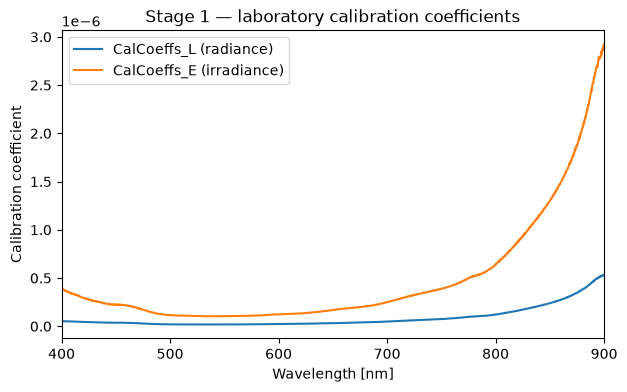

In [3]:
# Stage 1a: raw laboratory calibration scans - light (lg) and dark (dk) signal of the radiance (L) and
# irradiance (E) channels, integration time (IT), laboratory standards and detector non-linearity polynomial
L0 = load2d(f"{sensor}_L_lg_ITCorr_LabCal2023")            # raw radiance counts (light)
dark_L0 = load2d(f"{sensor}_L_dk_ITCorr_LabCal2023")        # raw radiance counts (dark)
IT_L0 = float(load(f"{sensor}_L_IT_Lab2023"))               # integration time used
E0 = load2d(f"{sensor}_E_lg_ITCorr_LabCal2023")
dark_E0 = load2d(f"{sensor}_E_dk_ITCorr_LabCal2023")
IT_E0 = float(load(f"{sensor}_E_IT_Lab2023"))

Radiance_SI = col(load(f"RadianceStd_{sensor}_Lab2023"))       # lab radiance standard
Irradiance_SI = col(load(f"IrradianceStd_{sensor}_Lab2023"))   # lab irradiance standard
C_nonlin = load(f"coeffsNonlin_{sensor}_Lab2023").reshape(-1)  # detector non-linearity polynomial

# Stage 1b: mean over the repeated scans (columns), one value per wavelength (rows)
L0_m = np.mean(L0, axis=1, keepdims=True)
dark_L0_m = np.mean(dark_L0, axis=1, keepdims=True)
E0_m = np.mean(E0, axis=1, keepdims=True)
dark_E0_m = np.mean(dark_E0, axis=1, keepdims=True)

# Integration-time-scaled, dark-corrected signal feeds the non-linearity correction
DataL0_Rad = apply_IT(L0, IT_L0); Datadark_Rad = apply_IT(dark_L0, IT_L0)
DataE0_Irrad = apply_IT(E0, IT_E0); Datadark_Irrad = apply_IT(dark_E0, IT_E0)
DN_DC_Rad = (DataL0_Rad - Datadark_Rad).mean(axis=1, keepdims=True)
DN_DC_Irrad = (DataE0_Irrad - Datadark_Irrad).mean(axis=1, keepdims=True)
# Stage 1c: non-linearity correction factor = 1 / polynomial(dark-corrected signal)
CorNonlin_L0 = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad[:, 0]))
CorNonlin_E0 = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad[:, 0]))

# Stage 1d: calibration coefficients (value)
CalCoeffs_L_nonlin = CalibrationCoeffsNonlin(L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0)
CalCoeffs_E_nonlin = CalibrationCoeffsNonlin(E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0)

# Random uncertainty: standard error across the repeat lab scans
# Stage 1e: random uncertainty of the signals = standard error over the repeated scans
L0_ur = np.std(L0, axis=1, ddof=1, keepdims=True) / np.sqrt(L0.shape[1])
dark_L0_ur = np.std(dark_L0, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0.shape[1])
E0_ur = np.std(E0, axis=1, ddof=1, keepdims=True) / np.sqrt(E0.shape[1])
dark_E0_ur = np.std(dark_E0, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0.shape[1])

# Stage 1f: propagate the random uncertainty through CalibrationCoeffsNonlin (punpy, propagate_random)
CalCoeffs_L_ur = prop.propagate_random(CalibrationCoeffsNonlin,
    [L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0],
    [L0_ur, dark_L0_ur, np.zeros_like(Radiance_SI), np.zeros_like(CorNonlin_L0)])
CalCoeffs_E_ur = prop.propagate_random(CalibrationCoeffsNonlin,
    [E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0],
    [E0_ur, dark_E0_ur, np.zeros_like(Irradiance_SI), np.zeros_like(CorNonlin_E0)])

# Systematic uncertainty: the lab standard's own calibration uncertainty + non-linearity residual
# Stage 1g: systematic uncertainty inputs = standard's own uncertainty and non-linearity residual
Radiance_us_abs = col(load(f"u_{sensor}_L_std_abs_Lab2023"))
Irradiance_us_abs = col(load(f"u_{sensor}_E_std_abs_Lab2023"))
CalCoeffs_nonlin_us_rel = col(load(f"u_{sensor}_nonlin_residual_Lab2023"))
CalCoeffsL0_nonlin_us_abs = CorNonlin_L0 * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_nonlin_us_abs = CorNonlin_E0 * (CalCoeffs_nonlin_us_rel / 100.0)

# Stage 1h: propagate the systematic uncertainty (fully correlated over wavelength, propagate_systematic)
CalCoeffs_L_us = prop.propagate_systematic(CalibrationCoeffsNonlin,
    [L0_m, dark_L0_m, Radiance_SI, CorNonlin_L0],
    [np.zeros_like(L0_m), np.zeros_like(dark_L0_m), Radiance_us_abs, CalCoeffsL0_nonlin_us_abs])
CalCoeffs_E_us = prop.propagate_systematic(CalibrationCoeffsNonlin,
    [E0_m, dark_E0_m, Irradiance_SI, CorNonlin_E0],
    [np.zeros_like(E0_m), np.zeros_like(dark_E0_m), Irradiance_us_abs, CalCoeffsE0_nonlin_us_abs])

print("Stage 1 (lab calibration) done.")

# Stage 1i: plot the calibration coefficients in the 400-900 nm window
wvlL_lab = load(f"{sensor}_L_Wavelength_Lab2023")
wvlE_lab = load(f"{sensor}_E_Wavelength_Lab2023")
mL_lab = (wvlL_lab >= WL_MIN) & (wvlL_lab <= WL_MAX)
mE_lab = (wvlE_lab >= WL_MIN) & (wvlE_lab <= WL_MAX)

plt.figure(figsize=(7, 4))
plt.plot(wvlL_lab[mL_lab], CalCoeffs_L_nonlin.ravel()[mL_lab], label='CalCoeffs_L (radiance)')
plt.plot(wvlE_lab[mE_lab], CalCoeffs_E_nonlin.ravel()[mE_lab], label='CalCoeffs_E (irradiance)')
plt.xlim(WL_MIN, WL_MAX)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Calibration coefficient')
plt.legend(); plt.title('Stage 1 — laboratory calibration coefficients')
plt.show()

## Stage 2 - Laboratory validation (ValGEOS)

Stage 2 (lab validation / ValGEOS) done.


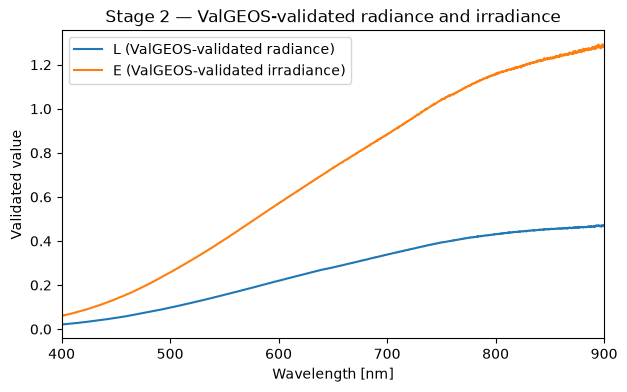

In [4]:
# Stage 2a: laboratory measurement of the transfer standard ValGEOS (light and dark scans)
L0_val = load2d(f"{sensor}_L_lg_ITCorr_LabVal2023")
dark_L0_val = load2d(f"{sensor}_L_dk_ITCorr_LabVal2023")
E0_val = load2d(f"{sensor}_E_lg_ITCorr_LabVal2023")
dark_E0_val = load2d(f"{sensor}_E_dk_ITCorr_LabVal2023")

# Stage 2b: mean over scans, integration-time scaling, dark correction and non-linearity correction,
# as in Stage 1
L0_m_val = np.mean(L0_val, axis=1, keepdims=True)
dark_L0_m_val = np.mean(dark_L0_val, axis=1, keepdims=True)
E0_m_val = np.mean(E0_val, axis=1, keepdims=True)
dark_E0_m_val = np.mean(dark_E0_val, axis=1, keepdims=True)

DataL0_Rad_val = apply_IT(L0_val, float(load(f"{sensor}_L_IT_ValLab2023")))
Datadark_Rad_val = apply_IT(dark_L0_val, float(load(f"{sensor}_L_IT_ValLab2023")))
DataE0_Irrad_val = apply_IT(E0_val, float(load(f"{sensor}_E_IT_ValLab2023")))
Datadark_Irrad_val = apply_IT(dark_E0_val, float(load(f"{sensor}_E_IT_ValLab2023")))
DN_DC_Rad_val = (DataL0_Rad_val - Datadark_Rad_val).mean(axis=1, keepdims=True)
DN_DC_Irrad_val = (DataE0_Irrad_val - Datadark_Irrad_val).mean(axis=1, keepdims=True)
CorNonlin_L0_val = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad_val[:, 0]))
CorNonlin_E0_val = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad_val[:, 0]))

# Stage 2c: ValGEOS radiance and irradiance obtained with the Stage 1 calibration coefficients (value)
Lvalgeos_nonlin = VALGEOSCalibrationNonlin(CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val)
Evalgeos_nonlin = VALGEOSCalibrationNonlin(CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val)

# Stage 2d: random uncertainty of the ValGEOS signals (standard error over scans)
L0_ur_val = np.std(L0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_val.shape[1])
dark_L0_ur_val = np.std(dark_L0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_val.shape[1])
E0_ur_val = np.std(E0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_val.shape[1])
dark_E0_ur_val = np.std(dark_E0_val, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_val.shape[1])

# Stage 2e: propagate the random uncertainty, including the Stage 1 coefficient's random uncertainty
Lvalgeos_ur = prop.propagate_random(VALGEOSCalibrationNonlin,
    [CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val],
    [CalCoeffs_L_ur, L0_ur_val, dark_L0_ur_val, np.zeros_like(CorNonlin_L0_val)])
Evalgeos_ur = prop.propagate_random(VALGEOSCalibrationNonlin,
    [CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val],
    [CalCoeffs_E_ur, E0_ur_val, dark_E0_ur_val, np.zeros_like(CorNonlin_E0_val)])

CalCoeffsL0_val_nonlin_us_abs = CorNonlin_L0_val * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_val_nonlin_us_abs = CorNonlin_E0_val * (CalCoeffs_nonlin_us_rel / 100.0)

# Stage 2f: propagate the systematic uncertainty, including the Stage 1 coefficient's systematic uncertainty
Lvalgeos_us = prop.propagate_systematic(VALGEOSCalibrationNonlin,
    [CalCoeffs_L_nonlin, L0_m_val, dark_L0_m_val, CorNonlin_L0_val],
    [CalCoeffs_L_us, np.zeros_like(L0_m_val), np.zeros_like(dark_L0_m_val), CalCoeffsL0_val_nonlin_us_abs])
Evalgeos_us = prop.propagate_systematic(VALGEOSCalibrationNonlin,
    [CalCoeffs_E_nonlin, E0_m_val, dark_E0_m_val, CorNonlin_E0_val],
    [CalCoeffs_E_us, np.zeros_like(E0_m_val), np.zeros_like(dark_E0_m_val), CalCoeffsE0_val_nonlin_us_abs])

print("Stage 2 (lab validation / ValGEOS) done.")

# Stage 2g: plot the ValGEOS-validated radiance and irradiance
wvlL_val = load(f"{sensor}_L_Wavelength_ValLab2023")
wvlE_val = load(f"{sensor}_E_Wavelength_ValLab2023")
mL_val = (wvlL_val >= WL_MIN) & (wvlL_val <= WL_MAX)
mE_val = (wvlE_val >= WL_MIN) & (wvlE_val <= WL_MAX)

plt.figure(figsize=(7, 4))
plt.plot(wvlL_val[mL_val], Lvalgeos_nonlin.ravel()[mL_val], label='L (ValGEOS-validated radiance)')
plt.plot(wvlE_val[mE_val], Evalgeos_nonlin.ravel()[mE_val], label='E (ValGEOS-validated irradiance)')
plt.xlim(WL_MIN, WL_MAX)
plt.xlabel('Wavelength [nm]'); plt.ylabel('Validated value')
plt.legend(); plt.title('Stage 2 — ValGEOS-validated radiance and irradiance')
plt.show()

## Stage 3 - Field calibration coefficients

Stage 3 (field calibration coefficients) done.


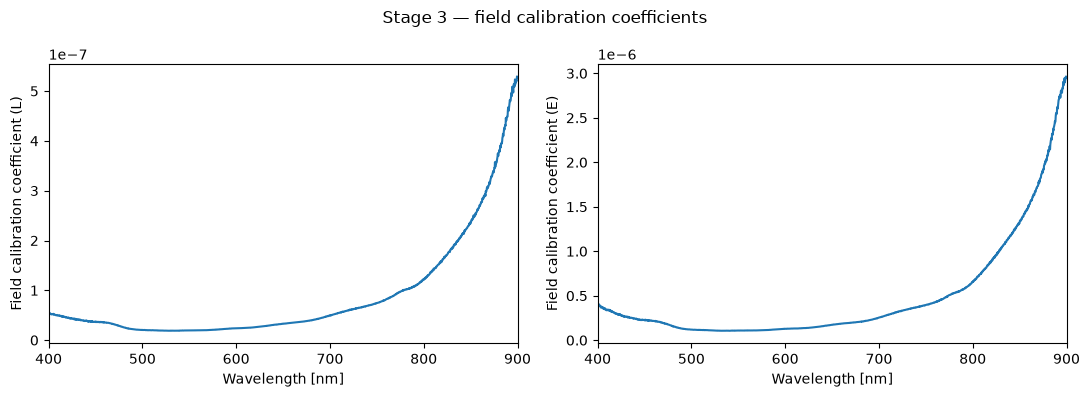

In [5]:
# Stage 3a: wavelength grid of the field campaign and the 400-900 nm mask
Wvl_L_val2025 = load(f"{sensor}_L_Wavelength_Val2025").reshape(-1, 1)
Wvl_E_val2025 = load(f"{sensor}_E_Wavelength_Val2025").reshape(-1, 1)
wvlL = Wvl_L_val2025.ravel(); wvlE = Wvl_E_val2025.ravel()
mask_wvlL = (wvlL >= WL_MIN) & (wvlL <= WL_MAX)
mask_wvlE = (wvlE >= WL_MIN) & (wvlE <= WL_MAX)

# Stage 3b: ValGEOS measured again in the field (2025): light and dark scans
L0_valF = load2d(f"{sensor}_L_lg_ITCorr_FieldVal2025")
dark_L0_valF = load2d(f"{sensor}_L_dk_ITCorr_FieldVal2025")
E0_valF = load2d(f"{sensor}_E_lg_ITCorr_FieldVal2025")
dark_E0_valF = load2d(f"{sensor}_E_dk_ITCorr_FieldVal2025")

# Stage 3c: mean over scans, integration-time scaling, dark correction and non-linearity correction
L0_m_valF = np.mean(L0_valF, axis=1, keepdims=True)
dark_L0_m_valF = np.mean(dark_L0_valF, axis=1, keepdims=True)
E0_m_valF = np.mean(E0_valF, axis=1, keepdims=True)
dark_E0_m_valF = np.mean(dark_E0_valF, axis=1, keepdims=True)

DataL0_Rad_valF = apply_IT(L0_valF, float(load(f"{sensor}_L_IT_Val2025")))
Datadark_Rad_valF = apply_IT(dark_L0_valF, float(load(f"{sensor}_L_IT_Val2025")))
DataE0_Irrad_valF = apply_IT(E0_valF, float(load(f"{sensor}_E_IT_Val2025")))
Datadark_Irrad_valF = apply_IT(dark_E0_valF, float(load(f"{sensor}_E_IT_Val2025")))
DN_DC_Rad_valF = (DataL0_Rad_valF - Datadark_Rad_valF).mean(axis=1, keepdims=True)
DN_DC_Irrad_valF = (DataE0_Irrad_valF - Datadark_Irrad_valF).mean(axis=1, keepdims=True)
CorNonlin_L0_valF = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad_valF[:, 0]))
CorNonlin_E0_valF = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad_valF[:, 0]))
CalCoeffsL0_valF_nonlin_us_abs = CorNonlin_L0_valF * (CalCoeffs_nonlin_us_rel / 100.0)
CalCoeffsE0_valF_nonlin_us_abs = CorNonlin_E0_valF * (CalCoeffs_nonlin_us_rel / 100.0)

# Stage 3d: field calibration coefficients = ValGEOS reference / field validation signal (value)
CalCoeffsL_valF_nonlin = FieldCalCoeffsNonlin(Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF)
CalCoeffsE_valF_nonlin = FieldCalCoeffsNonlin(Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF)

L0_ur_valF = np.std(L0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_valF.shape[1])
dark_L0_ur_valF = np.std(dark_L0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_valF.shape[1])
E0_ur_valF = np.std(E0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_valF.shape[1])
dark_E0_ur_valF = np.std(dark_E0_valF, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_valF.shape[1])

# Stage 3e: propagate random uncertainty (ValGEOS random uncertainty and field-scan standard error)
CalCoeffsL_valF_ur = prop.propagate_random(FieldCalCoeffsNonlin,
    [Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF],
    [Lvalgeos_ur, L0_ur_valF, dark_L0_ur_valF, np.zeros_like(CorNonlin_L0_valF)])
CalCoeffsE_valF_ur = prop.propagate_random(FieldCalCoeffsNonlin,
    [Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF],
    [Evalgeos_ur, E0_ur_valF, dark_E0_ur_valF, np.zeros_like(CorNonlin_E0_valF)])
# Stage 3f: propagate systematic uncertainty (ValGEOS systematic uncertainty and non-linearity residual)
CalCoeffsL_valF_us = prop.propagate_systematic(FieldCalCoeffsNonlin,
    [Lvalgeos_nonlin, L0_m_valF, dark_L0_m_valF, CorNonlin_L0_valF],
    [Lvalgeos_us, np.zeros_like(L0_m_valF), np.zeros_like(dark_L0_m_valF), CalCoeffsL0_valF_nonlin_us_abs])
CalCoeffsE_valF_us = prop.propagate_systematic(FieldCalCoeffsNonlin,
    [Evalgeos_nonlin, E0_m_valF, dark_E0_m_valF, CorNonlin_E0_valF],
    [Evalgeos_us, np.zeros_like(E0_m_valF), np.zeros_like(dark_E0_m_valF), CalCoeffsE0_valF_nonlin_us_abs])

print("Stage 3 (field calibration coefficients) done.")

# Stage 3g: plot the field calibration coefficients
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(wvlL[mask_wvlL], CalCoeffsL_valF_nonlin.ravel()[mask_wvlL])
axes[0].set_xlim(WL_MIN, WL_MAX)
axes[0].set_xlabel('Wavelength [nm]'); axes[0].set_ylabel('Field calibration coefficient (L)')
axes[1].plot(wvlE[mask_wvlE], CalCoeffsE_valF_nonlin.ravel()[mask_wvlE])
axes[1].set_xlim(WL_MIN, WL_MAX)
axes[1].set_xlabel('Wavelength [nm]'); axes[1].set_ylabel('Field calibration coefficient (E)')
fig.suptitle('Stage 3 — field calibration coefficients')
plt.tight_layout(); plt.show()

## Stage 4 - Field measurements, per point: radiance, irradiance and reflectance

Point 103p1: calibrated, reflectance computed.


Point 103p2: calibrated, reflectance computed.


Point 103p3: calibrated, reflectance computed.


Point 103p4: calibrated, reflectance computed.


Point 103p5: calibrated, reflectance computed.


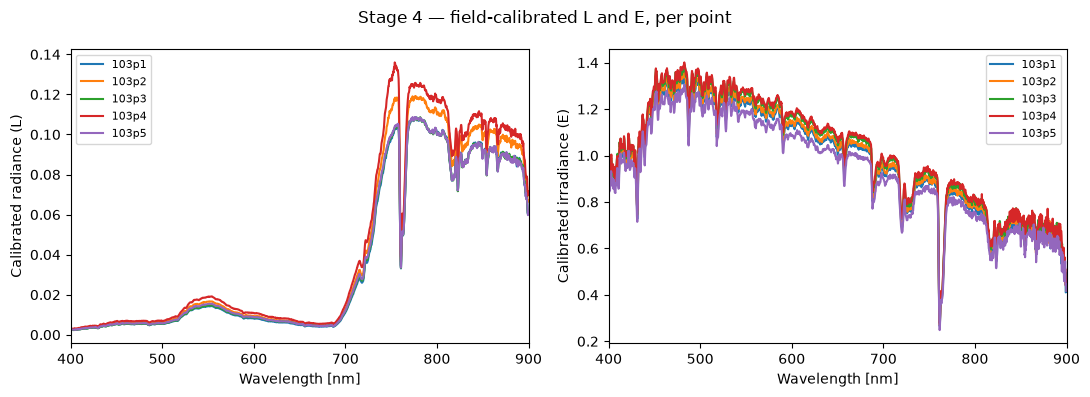

In [6]:
# Cosine response of the irradiance receptor: relative systematic uncertainty (9.94 % for Plot 103, set by the
# solar zenith angle), added to the systematic uncertainty of E as a rectangular distribution (divided by sqrt(3))
def cosine_u_abs_for_E(E_nonlin):
    # 9.94% relative uncertainty — the group Plot 103 belongs to (paper Results section)
    return 0.0994 * np.asarray(E_nonlin, float)

# Stage 4a: loop over the 5 measurement points of Plot 103
point_keys = [f"{plot_id}p{i}" for i in range(1, 6)]
L_F_nonlin, E_F_nonlin, R_F_nonlin = {}, {}, {}
L_F_ur, L_F_us, E_F_ur, E_F_us, R_F_ur, R_F_us = {}, {}, {}, {}, {}, {}

for pk in point_keys:
    # Stage 4b: raw field scans of this point (light, dark, integration time) for L and E
    L0_F = load2d(f"{sensor}_L_lg_ITCorr_Field2025_{pk}")
    dark_L0_F = load2d(f"{sensor}_L_dk_ITCorr_Field2025_{pk}")
    IT_L0_F = float(load(f"{sensor}_L_IT_Field2025_{pk}"))
    E0_F = load2d(f"{sensor}_E_lg_ITCorr_Field2025_{pk}")
    dark_E0_F = load2d(f"{sensor}_E_dk_ITCorr_Field2025_{pk}")
    IT_E0_F = float(load(f"{sensor}_E_IT_Field2025_{pk}"))

    # Stage 4c: integration-time scaling, dark correction and non-linearity correction
    DataL0_Rad = apply_IT(L0_F, IT_L0_F); Datadark_Rad = apply_IT(dark_L0_F, IT_L0_F)
    DataE0_Irrad = apply_IT(E0_F, IT_E0_F); Datadark_Irrad = apply_IT(dark_E0_F, IT_E0_F)
    L0_m_F = np.mean(L0_F, axis=1, keepdims=True); dark_L0_m_F = np.mean(dark_L0_F, axis=1, keepdims=True)
    E0_m_F = np.mean(E0_F, axis=1, keepdims=True); dark_E0_m_F = np.mean(dark_E0_F, axis=1, keepdims=True)
    DN_DC_Rad = (DataL0_Rad - Datadark_Rad).mean(axis=1, keepdims=True)
    DN_DC_Irrad = (DataE0_Irrad - Datadark_Irrad).mean(axis=1, keepdims=True)
    CorNonlin_L0_F = col(1.0 / np.polyval(C_nonlin, DN_DC_Rad[:, 0]))
    CorNonlin_E0_F = col(1.0 / np.polyval(C_nonlin, DN_DC_Irrad[:, 0]))
    CorNonlin_L0_F_us_abs = CorNonlin_L0_F * (CalCoeffs_nonlin_us_rel / 100.0)
    CorNonlin_E0_F_us_abs = CorNonlin_E0_F * (CalCoeffs_nonlin_us_rel / 100.0)

    # Stage 4d: calibrated radiance and irradiance (field coefficient applied to the field signal)
    L_nonlin = FieldRadianceNonlin(CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F)
    E_nonlin = FieldRadianceNonlin(CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F)

    # Stage 4e: random uncertainty of the field signals (standard error over scans)
    L0_ur_F = np.std(L0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(L0_F.shape[1])
    dark_L0_ur_F = np.std(dark_L0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_L0_F.shape[1])
    E0_ur_F = np.std(E0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(E0_F.shape[1])
    dark_E0_ur_F = np.std(dark_E0_F, axis=1, ddof=1, keepdims=True) / np.sqrt(dark_E0_F.shape[1])

    # Stage 4f: propagate random uncertainty through FieldRadianceNonlin (coefficient + signal)
    L_ur = prop.propagate_random(FieldRadianceNonlin,
        [CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F],
        [CalCoeffsL_valF_ur, L0_ur_F, dark_L0_ur_F, np.zeros_like(CorNonlin_L0_F)])
    E_ur = prop.propagate_random(FieldRadianceNonlin,
        [CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F],
        [CalCoeffsE_valF_ur, E0_ur_F, dark_E0_ur_F, np.zeros_like(CorNonlin_E0_F)])
    # Stage 4g: propagate systematic uncertainty through FieldRadianceNonlin (coefficient + non-linearity)
    L_us = prop.propagate_systematic(FieldRadianceNonlin,
        [CalCoeffsL_valF_nonlin, L0_m_F, dark_L0_m_F, CorNonlin_L0_F],
        [CalCoeffsL_valF_us, np.zeros_like(L0_m_F), np.zeros_like(dark_L0_m_F), CorNonlin_L0_F_us_abs])
    E_us = prop.propagate_systematic(FieldRadianceNonlin,
        [CalCoeffsE_valF_nonlin, E0_m_F, dark_E0_m_F, CorNonlin_E0_F],
        [CalCoeffsE_valF_us, np.zeros_like(E0_m_F), np.zeros_like(dark_E0_m_F), CorNonlin_E0_F_us_abs])

    # Stage 4h: add the cosine-response uncertainty to the systematic uncertainty of E (quadrature)
    # add the cosine-response systematic component onto E (rectangular distribution -> /sqrt(3))
    uE_cos_abs = cosine_u_abs_for_E(E_nonlin)
    E_us = np.sqrt(np.asarray(E_us, float)**2 + (uE_cos_abs / np.sqrt(3))**2)

    # Stage 4i: reflectance R = pi*L/E and its random and systematic uncertainty (propagated through the ratio)
    R_nonlin = Reflectance(L_nonlin, E_nonlin)
    R_ur = prop.propagate_random(Reflectance, [L_nonlin, E_nonlin], [L_ur, E_ur])
    R_us = prop.propagate_systematic(Reflectance, [L_nonlin, E_nonlin], [L_us, E_us])

    L_F_nonlin[pk] = L_nonlin; E_F_nonlin[pk] = E_nonlin; R_F_nonlin[pk] = R_nonlin
    L_F_ur[pk] = L_ur; L_F_us[pk] = L_us; E_F_ur[pk] = E_ur; E_F_us[pk] = E_us
    R_F_ur[pk] = R_ur; R_F_us[pk] = R_us
    print(f"Point {pk}: calibrated, reflectance computed.")

# Stage 4j: plot the calibrated radiance and irradiance of the 5 points
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for pk in point_keys:
    axes[0].plot(wvlL[mask_wvlL], np.asarray(L_F_nonlin[pk]).ravel()[mask_wvlL], label=pk)
    axes[1].plot(wvlE[mask_wvlE], np.asarray(E_F_nonlin[pk]).ravel()[mask_wvlE], label=pk)
axes[0].set_xlim(WL_MIN, WL_MAX); axes[1].set_xlim(WL_MIN, WL_MAX)
axes[0].set_xlabel('Wavelength [nm]'); axes[0].set_ylabel('Calibrated radiance (L)')
axes[1].set_xlabel('Wavelength [nm]'); axes[1].set_ylabel('Calibrated irradiance (E)')
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
fig.suptitle('Stage 4 — field-calibrated L and E, per point')
plt.tight_layout(); plt.show()

## Stage 4b - Plot-level mean over the 5 points

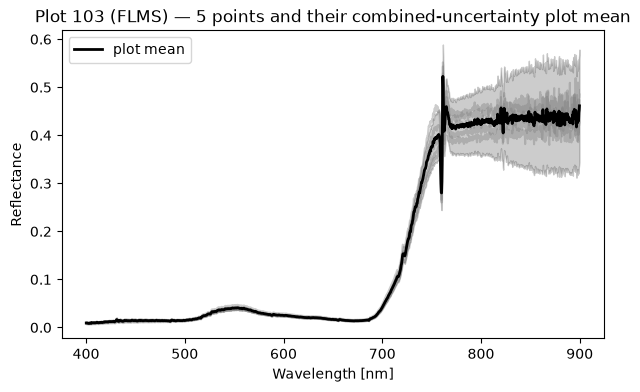

In [7]:
# Plot mean over the N points: u_random = sqrt( (sqrt(sum u_r,i^2)/N)^2 + (std of the points/sqrt(N))^2 ), i.e. the
# averaged random uncertainty plus the point-to-point spread (plot heterogeneity); u_systematic = mean of the points'
# u_s (averaging does not reduce it, it is the same for every point); combined = sqrt(u_random^2 + u_systematic^2)
def propagate_plot_mean_with_components_fast(vals_list, ur_list, us_list, add_variability=True, ddof=1):
    V = np.stack([np.asarray(v, float).reshape(-1) for v in vals_list], axis=1)
    UR = np.stack([np.asarray(u, float).reshape(-1) for u in ur_list], axis=1)
    US = np.stack([np.asarray(u, float).reshape(-1) for u in us_list], axis=1)
    Np = V.shape[1]
    mean = np.mean(V, axis=1)
    u_r = np.sqrt(np.sum(UR**2, axis=1)) / Np
    if add_variability:
        u_var = np.std(V, axis=1, ddof=ddof) / np.sqrt(Np)   # point-to-point spread, added as extra randomness
        u_r = np.sqrt(u_r**2 + u_var**2)
    u_s = np.mean(US, axis=1)
    u_c = np.sqrt(u_r**2 + u_s**2)
    return mean.reshape(-1, 1), u_r.reshape(-1, 1), u_s.reshape(-1, 1), u_c.reshape(-1, 1)


# Apply the plot-mean function to the 5 reflectance spectra
R_vals = [R_F_nonlin[pk] for pk in point_keys]
R_urs = [R_F_ur[pk] for pk in point_keys]
R_uss = [R_F_us[pk] for pk in point_keys]
R_mean, R_u_r_mean, R_u_s_mean, R_u_c_mean = propagate_plot_mean_with_components_fast(R_vals, R_urs, R_uss)

# Mask (reflectance > 0, 400-900 nm) used for plotting
Rm = np.asarray(R_mean).ravel()
ucRm = np.asarray(R_u_c_mean).ravel()
mR = (Rm > 1e-12) & mask_wvlL

# Plot: the 5 points (grey) and the plot mean with its combined uncertainty
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for pk in point_keys:
    plt.plot(wvlL[mR], np.asarray(R_F_nonlin[pk]).ravel()[mR], color='grey', alpha=0.4)
plt.plot(wvlL[mR], Rm[mR], color='k', linewidth=2, label='plot mean')
plt.fill_between(wvlL[mR], Rm[mR] - ucRm[mR], Rm[mR] + ucRm[mR], alpha=0.2, color='k')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend()
plt.title('Plot 103 (FLMS) — 5 points and their combined-uncertainty plot mean')
plt.show()

## Stage 5 - Vegetation indices, per point

In [8]:
# Stage 5a: bands (indices into the FLMS wavelength grid) used for the indices; the wavelengths used are printed
# Band positions (index into the FLMS wavelength grid) for the 5 indices
idx_480, idx_531, idx_570 = 381, 522, 632
idx_670, idx_681, idx_709, idx_754, idx_780 = 923, 956, 1040, 1177, 1257

# Reflectance, random and systematic uncertainty at one band
def band_values(R, ur, us, idx):
    return float(R[idx]), float(ur[idx]), float(us[idx])

# Stage 5b: for each point, compute each index and propagate the uncertainty through the index formula with punpy:
# propagate_random for the random part, propagate_systematic (correlation matrix corr2 / corr3: the bands share the
# same systematic error) for the systematic part
index_rows = []
for pk in point_keys:
    R = np.asarray(R_F_nonlin[pk]).ravel()
    ur = np.asarray(R_F_ur[pk]).ravel()
    us = np.asarray(R_F_us[pk]).ravel()

    # PRI uses the 570 and 531 nm bands (2 bands)
    R570, ur570, us570 = band_values(R, ur, us, idx_570)
    R531, ur531, us531 = band_values(R, ur, us, idx_531)
    PRI_val = float(PRI_fun(R570, R531))
    PRI_ur = float(np.asarray(prop.propagate_random(PRI_fun, [a1(R570), a1(R531)], [a1(ur570), a1(ur531)])).ravel()[0])
    PRI_us = float(np.asarray(prop.propagate_systematic(PRI_fun, [a1(R570), a1(R531)], [a1(us570), a1(us531)], corr_between=corr2)).ravel()[0])

    # NDVI uses the 780 and 670 nm bands (2 bands)
    R670, ur670, us670 = band_values(R, ur, us, idx_670)
    R780, ur780, us780 = band_values(R, ur, us, idx_780)
    NDVI_val = float(NDVI_fun(R780, R670))
    NDVI_ur = float(np.asarray(prop.propagate_random(NDVI_fun, [a1(R780), a1(R670)], [a1(ur780), a1(ur670)])).ravel()[0])
    NDVI_us = float(np.asarray(prop.propagate_systematic(NDVI_fun, [a1(R780), a1(R670)], [a1(us780), a1(us670)], corr_between=corr2)).ravel()[0])

    # EVI uses the 780, 670 and 480 nm bands (3 bands)
    R480, ur480, us480 = band_values(R, ur, us, idx_480)
    EVI_val = float(EVI_fun(R480, R670, R780))
    EVI_ur = float(np.asarray(prop.propagate_random(EVI_fun, [a1(R480), a1(R670), a1(R780)], [a1(ur480), a1(ur670), a1(ur780)])).ravel()[0])
    EVI_us = float(np.asarray(prop.propagate_systematic(EVI_fun, [a1(R480), a1(R670), a1(R780)], [a1(us480), a1(us670), a1(us780)], corr_between=corr3)).ravel()[0])

    # MTCI uses the 754, 709 and 681 nm bands (3 bands)
    R681, ur681, us681 = band_values(R, ur, us, idx_681)
    R709, ur709, us709 = band_values(R, ur, us, idx_709)
    R754, ur754, us754 = band_values(R, ur, us, idx_754)
    MTCI_val = float(MTCI_fun(R681, R709, R754))
    MTCI_ur = float(np.asarray(prop.propagate_random(MTCI_fun, [a1(R681), a1(R709), a1(R754)], [a1(ur681), a1(ur709), a1(ur754)])).ravel()[0])
    MTCI_us = float(np.asarray(prop.propagate_systematic(MTCI_fun, [a1(R681), a1(R709), a1(R754)], [a1(us681), a1(us709), a1(us754)], corr_between=corr3)).ravel()[0])

    # OSAVI uses the 670 and 780 nm bands (2 bands)
    OSAVI_val = float(OSAVI_fun(R670, R780))
    OSAVI_ur = float(np.asarray(prop.propagate_random(OSAVI_fun, [a1(R670), a1(R780)], [a1(ur670), a1(ur780)])).ravel()[0])
    OSAVI_us = float(np.asarray(prop.propagate_systematic(OSAVI_fun, [a1(R670), a1(R780)], [a1(us670), a1(us780)], corr_between=corr2)).ravel()[0])

    index_rows.append(dict(point=pk, NDVI=NDVI_val, NDVI_u_r=NDVI_ur, NDVI_u_s=NDVI_us,
                            EVI=EVI_val, EVI_u_r=EVI_ur, EVI_u_s=EVI_us,
                            OSAVI=OSAVI_val, OSAVI_u_r=OSAVI_ur, OSAVI_u_s=OSAVI_us,
                            MTCI=MTCI_val, MTCI_u_r=MTCI_ur, MTCI_u_s=MTCI_us,
                            PRI=PRI_val, PRI_u_r=PRI_ur, PRI_u_s=PRI_us))

# Stage 5c: table with the indices and their random (u_r) and systematic (u_s) uncertainty
indices_df = pd.DataFrame(index_rows)
indices_df

,point,NDVI,NDVI_u_r,NDVI_u_s,EVI,EVI_u_r,EVI_u_s,OSAVI,OSAVI_u_r,OSAVI_u_s,MTCI,MTCI_u_r,MTCI_u_s,PRI,PRI_u_r,PRI_u_s
0,103p1,0.940506,0.001214,0.002403,0.710648,0.008795,0.075775,0.788711,0.004390,0.032440,5.538468,0.172437,0.117200,0.007140,0.008584,0.006231
1,103p2,0.937279,0.000992,0.002787,0.747541,0.005469,0.078918,0.801502,0.002600,0.031922,5.508227,0.087890,0.113378,0.010378,0.004152,0.005708
2,103p3,0.934399,0.000905,0.002735,0.684713,0.005261,0.074067,0.775041,0.002740,0.033247,5.262694,0.104161,0.127801,0.019541,0.005028,0.006020
3,103p4,0.932366,0.001007,0.002924,0.757170,0.003240,0.079761,0.802833,0.001454,0.031866,5.296153,0.099652,0.107325,0.010173,0.010391,0.005009
4,103p5,0.936104,0.001368,0.002808,0.731521,0.007228,0.078245,0.794959,0.003383,0.032556,5.073973,0.103824,0.108717,0.011041,0.009098,0.006832


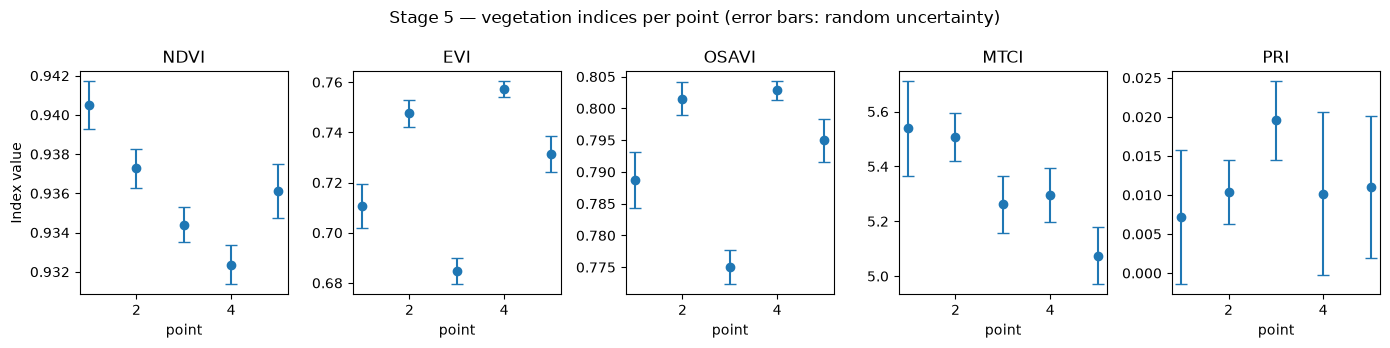

In [9]:
# Stage 5d: plot the indices per point (coloured points; error bars = combined uncertainty)
fig, axes = plt.subplots(1, 5, figsize=(14, 3.5), sharex=True)
for ax, name in zip(axes, ['NDVI', 'EVI', 'OSAVI', 'MTCI', 'PRI']):
    ax.errorbar(range(1, 6), indices_df[name], yerr=indices_df[f'{name}_u_r'], fmt='o', capsize=4)
    ax.set_title(name); ax.set_xlabel('point')
axes[0].set_ylabel('Index value')
plt.suptitle('Stage 5 — vegetation indices per point (error bars: random uncertainty)')
plt.tight_layout(); plt.show()

## Stage 6 - Comparison with the campaign indices

In [10]:

# Stage 6: comparison with the campaign indices (workbook Indexes-7_cos_16062026.xlsx, sheet Indexes103, FLMS rows,
# 5 points). The index values are deterministic; the uncertainties come from a Monte Carlo propagation,
# so they agree to within the sampling noise of the method.
campaign_idx = pd.read_excel(DATA_DIR / "../case-intercomparison-plot103-full/Indexes-7_cos_16062026.xlsx",
                             sheet_name="Indexes103", header=1).iloc[:5]

rows = []
for name in ['NDVI', 'EVI', 'OSAVI', 'MTCI', 'PRI']:
    rows.append(dict(index=name,
        max_abs_diff_value=np.max(np.abs(indices_df[name].values - campaign_idx[name].values.astype(float))),
        max_rel_diff_u_r_pct=100*np.max(np.abs(indices_df[f'{name}_u_r'].values / campaign_idx[f'{name}_u_r'].values.astype(float) - 1)),
        max_rel_diff_u_s_pct=100*np.max(np.abs(indices_df[f'{name}_u_s'].values / campaign_idx[f'{name}_u_s'].values.astype(float) - 1))))
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3g}"))


index  max_abs_diff_value  max_rel_diff_u_r_pct  max_rel_diff_u_s_pct
 NDVI            3.33e-16                 0.954                  7.81
  EVI            5.55e-16                  2.86                  4.09
OSAVI            2.22e-16                   4.1                  2.55
 MTCI            3.55e-15                   2.9                  11.9
  PRI            4.51e-17                 0.924                  28.5


---

**Reference:** Werfeli, M., Antala, M., Abdelmajeed, A.Y.A. et al. *"Uncertainty propagation and
intercomparison of multi-sensor measurements of vegetation stress in
sub-optimal conditions."* Precision Agric 27, 153 (2026).
https://doi.org/10.1007/s11119-026-10455-1

**Code:** L. Mihai (laura.mihai@inflpr.ro)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)